In [122]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import zscore

In [123]:
df = pd.read_csv(
        "reliability_dataset1.csv")

## Executive Summary

In [124]:
def show_dataset_summary(df):

    print("\n========== DATASET OVERVIEW ==========\n")

    print("Total Devices :", len(df))

    print(
        "\nTest Type Distribution:\n"
    )

    print(
        df["Test_Type"].value_counts()
    )

    print(
        "\nCensoring Summary:\n"
    )

    print(
        df["Censored"].value_counts()
    )

    print(
        "\nNumerical Summary:\n"
    )

    print(
        df[
            [
                "Stress_Temperature_C",
                "Stress_Voltage_V",
                "Humidity_Percent",
                "Failure_Time_Hours"
            ]
        ].describe().to_string()  ## used ".to_string()" to see all the columns, otherwise Pandas will hide the last column just to fit into the screen
    )


show_dataset_summary(df)


========== DATASET OVERVIEW ==========

Total Devices : 11200

Test Type Distribution:

Test_Type
HTOL    7200
THB     2400
TC      1600
Name: count, dtype: int64

Censoring Summary:

Censored
0    8364
1    2836
Name: count, dtype: int64

Numerical Summary:

       Stress_Temperature_C  Stress_Voltage_V  Humidity_Percent  Failure_Time_Hours
count          11200.000000      11200.000000      11200.000000        11200.000000
mean             104.642857          3.600000         44.285714          915.740636
std               46.272401          1.580758         11.157998          572.288492
min              -40.000000          0.000000         40.000000            5.421740
25%               85.000000          3.300000         40.000000          394.582289
50%              112.500000          4.000000         40.000000          819.406277
75%              125.000000          4.500000         40.000000         1500.000000
max              150.000000          5.000000         80.000000    

# RELIABILITY CORRELATION ANALYSIS

## Overall Dataset Heatmap

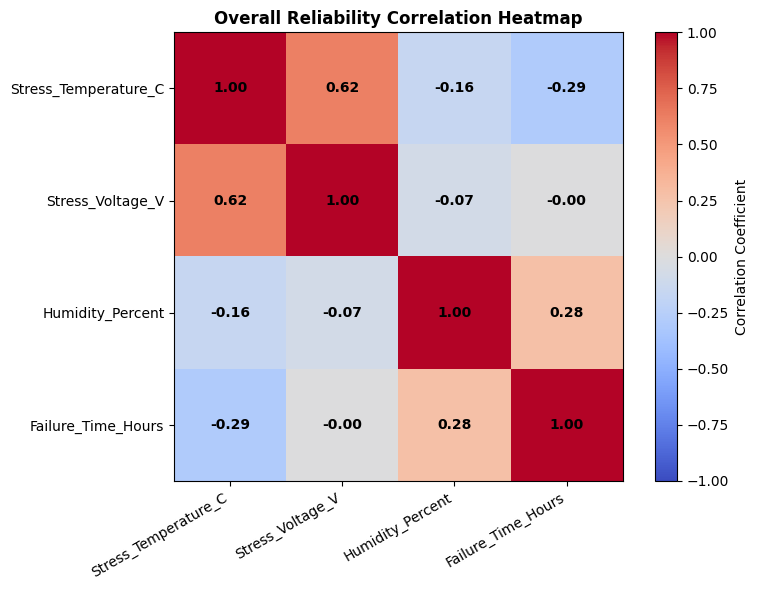


Overall Correlation Matrix

                      Stress_Temperature_C  Stress_Voltage_V  \
Stress_Temperature_C                 1.000             0.615   
Stress_Voltage_V                     0.615             1.000   
Humidity_Percent                    -0.163            -0.073   
Failure_Time_Hours                  -0.290            -0.003   

                      Humidity_Percent  Failure_Time_Hours  
Stress_Temperature_C            -0.163              -0.290  
Stress_Voltage_V                -0.073              -0.003  
Humidity_Percent                 1.000               0.277  
Failure_Time_Hours               0.277               1.000  


In [125]:

def overall_reliability_heatmap(df):

    correlation_matrix = (
        df[
            [
                "Stress_Temperature_C",
                "Stress_Voltage_V",
                "Humidity_Percent",
                "Failure_Time_Hours"
            ]
        ]
        .corr()
    )

    plt.figure(
        figsize=(8,6)
    )

    image = plt.imshow(
        correlation_matrix,
        cmap="coolwarm",
        vmin=-1,
        vmax=1
    )

    plt.colorbar(
        image,
        label="Correlation Coefficient"
    )

    columns = correlation_matrix.columns

    plt.xticks(
        range(len(columns)),
        columns,
        rotation=30,
        ha="right"
    )

    plt.yticks(
        range(len(columns)),
        columns
    )

    for i in range(len(columns)):
        for j in range(len(columns)):

            value = (
                correlation_matrix
                .iloc[i,j]
            )

            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontweight="bold"
            )

    plt.title(
        "Overall Reliability Correlation Heatmap",
        fontweight="bold"
    )

    plt.tight_layout()

    plt.show()

    print("\nOverall Correlation Matrix\n")

    print(
        correlation_matrix.round(3)
    )
overall_reliability_heatmap(df)



Overall correlation analysis provides a dataset-level overview. Stress-specific analyses are performed separately for physically meaningful interpretation.

## HTOL Heatmap

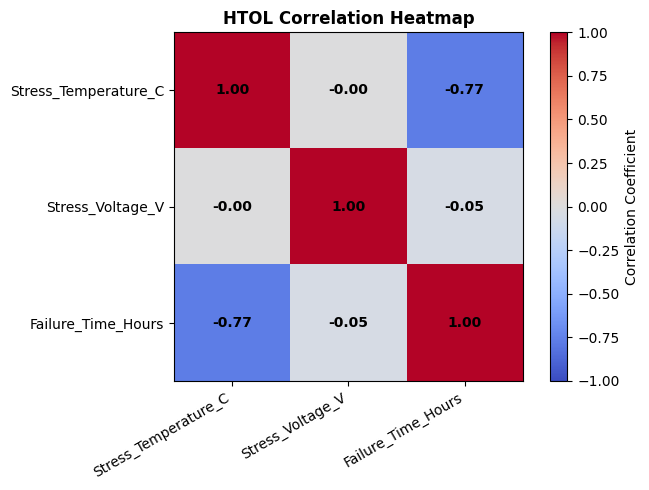


HTOL Correlation Matrix

                      Stress_Temperature_C  Stress_Voltage_V  \
Stress_Temperature_C                 1.000            -0.000   
Stress_Voltage_V                    -0.000             1.000   
Failure_Time_Hours                  -0.768            -0.047   

                      Failure_Time_Hours  
Stress_Temperature_C              -0.768  
Stress_Voltage_V                  -0.047  
Failure_Time_Hours                 1.000  

Dominant HTOL Reliability Driver : Stress_Temperature_C


In [126]:

def htol_heatmap(df):

    htol = df[
        df["Test_Type"] == "HTOL"
    ]

    correlation_matrix = (
        htol[
            [
                "Stress_Temperature_C",
                "Stress_Voltage_V",
                "Failure_Time_Hours"
            ]
        ]
        .corr()
    )

    plt.figure(
        figsize=(7,5)
    )

    image = plt.imshow(
        correlation_matrix,
        cmap="coolwarm",
        vmin=-1,
        vmax=1
    )

    plt.colorbar(
        image,
        label="Correlation Coefficient"
    )

    columns = correlation_matrix.columns

    plt.xticks(
        range(len(columns)),
        columns,
        rotation=30,
        ha="right"
    )

    plt.yticks(
        range(len(columns)),
        columns
    )

    for i in range(len(columns)):
        for j in range(len(columns)):

            value = (
                correlation_matrix
                .iloc[i,j]
            )

            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontweight="bold"
            )

    plt.title(
        "HTOL Correlation Heatmap",
        fontweight="bold"
    )

    plt.tight_layout()

    plt.show()

    print("\nHTOL Correlation Matrix\n")

    print(
        correlation_matrix.round(3)
    )

    lifetime_corr = (
        correlation_matrix[
            "Failure_Time_Hours"
        ]
        .drop(
            "Failure_Time_Hours"
        )
    )

    strongest_driver = (
        lifetime_corr.abs()
        .idxmax()
    )

    print(
        f"\nDominant HTOL Reliability Driver : {strongest_driver}"
    )

htol_heatmap(df)


## THB Humidity Analysis



THB HUMIDITY ANALYSIS
                         mean  median         std
Humidity_Percent                                 
40                1412.596179  1500.0  252.589776
60                1375.094031  1500.0  280.526832
80                1305.199495  1500.0  344.324355


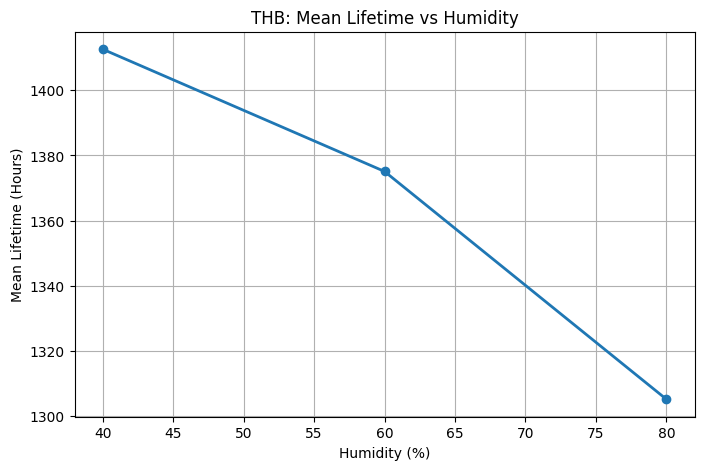

In [127]:
def thb_humidity_analysis(df):

    thb = df[
        df["Test_Type"] == "THB"
    ]

    result = (
        thb.groupby(
            "Humidity_Percent"
        )[
            "Failure_Time_Hours"
        ]
        .agg(
            [
                "mean",
                "median",
                "std"
            ]
        )
    )

    print("\n")
    print("="*60)
    print("THB HUMIDITY ANALYSIS")
    print("="*60)

    print(result)

    plt.figure(
        figsize=(8,5)
    )

    plt.plot(
        result.index,
        result["mean"],
        marker="o",
        linewidth=2
    )

    plt.title(
        "THB: Mean Lifetime vs Humidity"
    )

    plt.xlabel(
        "Humidity (%)"
    )

    plt.ylabel(
        "Mean Lifetime (Hours)"
    )

    plt.grid(True)

    plt.show()
thb_humidity_analysis(df)



## TC Analysis

                            mean      median         std
Stress_Temperature_C                                    
-40                   722.445822  714.244268  349.324954
 125                  734.793850  722.300424  346.816808


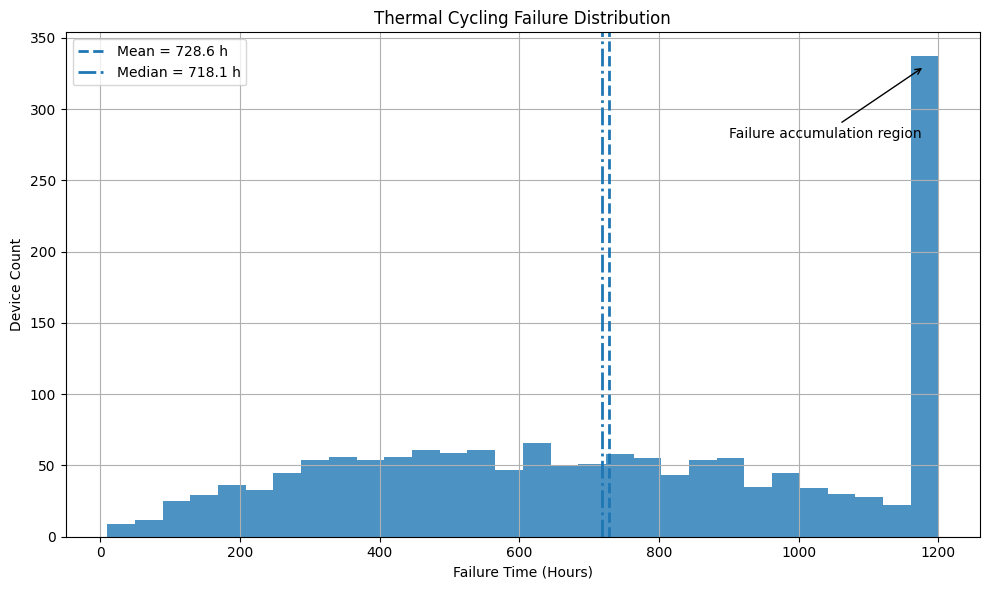

In [128]:
def tc_distribution_analysis(df):

    tc = df[
        df["Test_Type"] == "TC"
    ]
    result = (
        tc.groupby(
            "Stress_Temperature_C"
        )[
            "Failure_Time_Hours"
        ]
        .agg(
            [
                "mean",
                "median",
                "std"
            ]
        )
    )
    print(result)
    mean_life = (
        tc[
            "Failure_Time_Hours"
        ]
        .mean()
    )

    median_life = (
        tc[
            "Failure_Time_Hours"
        ]
        .median()
    )

    plt.figure(
        figsize=(10,6)
    )

    plt.annotate(
    "Failure accumulation region",
    xy=(1180,330),
    xytext=(900,280),
    arrowprops=dict(
        arrowstyle="->"
    )
    )

    plt.hist(
        tc[
            "Failure_Time_Hours"
        ],
        bins=30,
        alpha=0.8
    )

    plt.axvline(
        mean_life,
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean_life:.1f} h"
    )

    plt.axvline(
        median_life,
        linestyle="-.",
        linewidth=2,
        label=f"Median = {median_life:.1f} h"
    )

    plt.title(
        "Thermal Cycling Failure Distribution"
    )

    plt.xlabel(
        "Failure Time (Hours)"
    )

    plt.ylabel(
        "Device Count"
    )

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

tc_distribution_analysis(df)

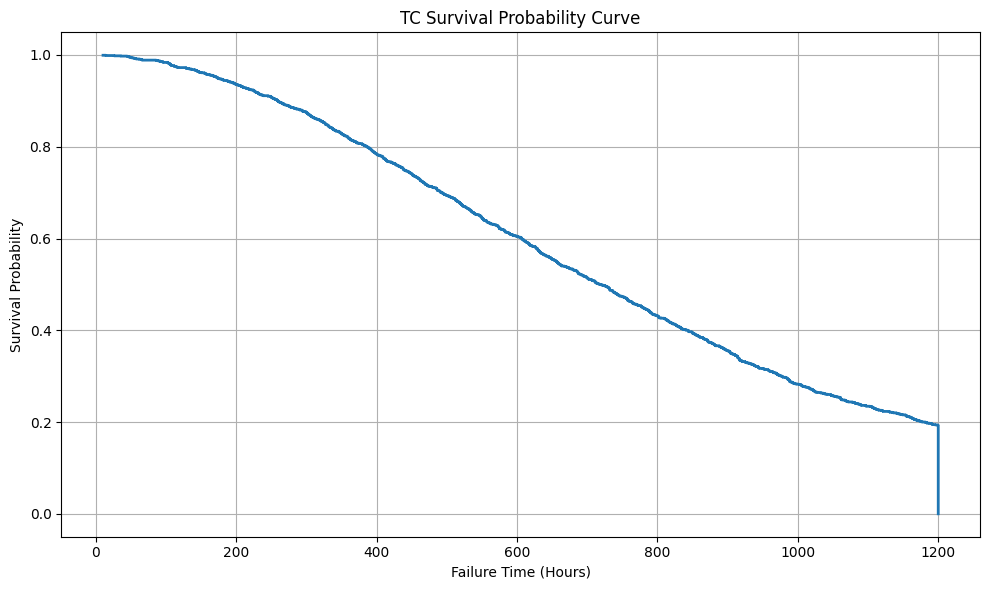

In [129]:

def tc_survival_analysis(df):

    tc = df[
        df["Test_Type"] == "TC"
    ].copy()

    tc = tc.sort_values(
        "Failure_Time_Hours"
    )

    failure_times = (
        tc[
            "Failure_Time_Hours"
        ]
        .values
    )

    survival_probability = (
        1
        -
        np.arange(
            1,
            len(failure_times)+1
        )
        /
        len(failure_times)
    )

    plt.figure(
        figsize=(10,6)
    )

    plt.step(
        failure_times,
        survival_probability,
        where="post",
        linewidth=2
    )

    plt.title(
        "TC Survival Probability Curve"
    )

    plt.xlabel(
        "Failure Time (Hours)"
    )

    plt.ylabel(
        "Survival Probability"
    )

    plt.grid(True)

    plt.tight_layout()

    plt.show()
tc_survival_analysis(df)

This survival curve shows the probability that a device remains operational under thermal cycling stress as a function of time.

## Temperature Impact Analysis

                             mean       median         std        min  \
Stress_Temperature_C                                                    
-40                    722.445822   714.244268  349.324954  10.188798   
 85                   1364.296568  1500.000000  298.207367  83.007820   
 100                  1444.554640  1535.194806  535.116853  83.374709   
 125                   688.432975   649.398739  341.329743  14.005919   
 150                   305.879184   292.349330  152.018099   5.421740   

                             max  
Stress_Temperature_C              
-40                   1200.00000  
 85                   1500.00000  
 100                  2000.00000  
 125                  2000.00000  
 150                  1030.87848  


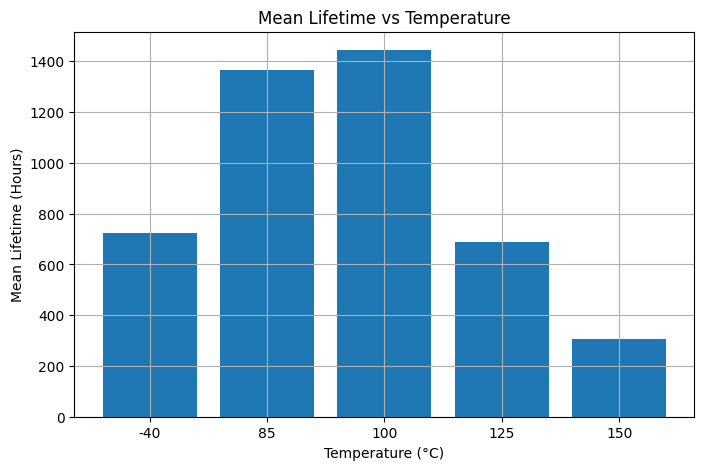

In [130]:
def analyze_temperature_effect(df):

    result = (
        df.groupby(
            "Stress_Temperature_C"
        )[
            "Failure_Time_Hours"
        ]
        .agg(
            [
                "mean",
                "median",
                "std",
                "min",
                "max"
            ]
        )
    )

    print(result)

    plt.figure(
        figsize=(8,5)
    )

    plt.bar(
        result.index.astype(str),
        result["mean"]
    )

    plt.title(
        "Mean Lifetime vs Temperature"
    )

    plt.xlabel(
        "Temperature (°C)"
    )

    plt.ylabel(
        "Mean Lifetime (Hours)"
    )

    plt.grid(True)

    plt.show()


analyze_temperature_effect(df)

## Voltage Impact Analysis

                         mean       median         std
Stress_Voltage_V                                      
0.0                728.619836   718.078698  348.019086
3.3               1364.296568  1500.000000  298.207367
4.0                843.370848   619.416099  618.164453
4.5                806.317801   603.744757  603.491754
5.0                773.724526   564.509117  592.351947


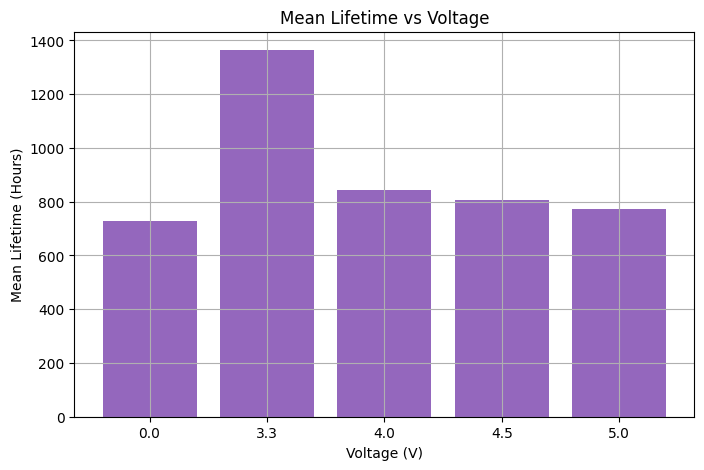

In [131]:
def analyze_voltage_effect(df):

    result = (
        df.groupby(
            "Stress_Voltage_V"
        )[
            "Failure_Time_Hours"
        ]
        .agg(
            [
                "mean",
                "median",
                "std"
            ]
        )
    )

    print(result)

    plt.figure(
        figsize=(8,5)
    )

    for i, value in enumerate(result["mean"]):
        
        plt.bar(
        result.index.astype(str),
        result["mean"]
    )

    plt.title(
        "Mean Lifetime vs Voltage"
    )

    plt.xlabel(
        "Voltage (V)"
    )

    plt.ylabel(
        "Mean Lifetime (Hours)"
    )

    plt.grid(True)

    plt.show()


analyze_voltage_effect(df)

## Boxplot Analysis

C:\Users\anami\AppData\Local\Temp\ipykernel_20580\3052673681.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


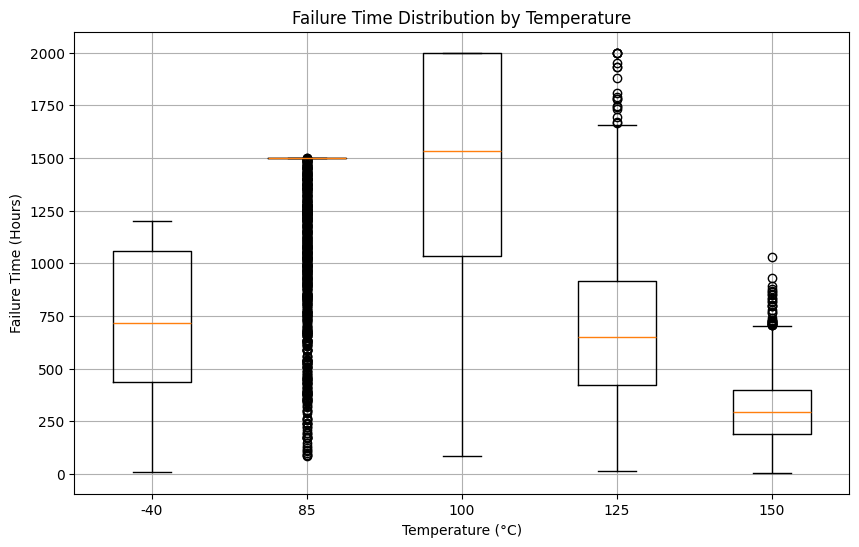

In [132]:
def show_boxplots(df):

    plt.figure(
        figsize=(10,6)
    )

    temperature_groups = []

    temperatures = sorted(
        df[
            "Stress_Temperature_C"
        ].unique()
    )

    for temp in temperatures:

        data = df.loc[
            df[
                "Stress_Temperature_C"
            ]
            ==
            temp,
            "Failure_Time_Hours"
        ]

        temperature_groups.append(
            data
        )

    plt.boxplot(
        temperature_groups,
        labels=temperatures
    )

    plt.title(
        "Failure Time Distribution by Temperature"
    )

    plt.xlabel(
        "Temperature (°C)"
    )

    plt.ylabel(
        "Failure Time (Hours)"
    )

    plt.grid(True)

    plt.show()


show_boxplots(df)

## Distribution Analysis

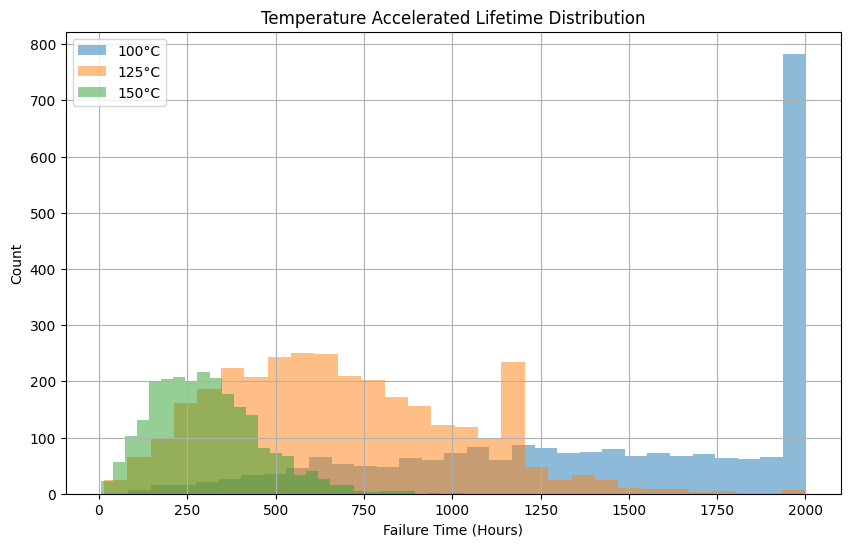

In [133]:
def show_distribution_analysis(df):

    temperatures = [100,125,150]

    plt.figure(
        figsize=(10,6)
    )

    for temp in temperatures:

        subset = df[
            df[
                "Stress_Temperature_C"
            ]
            ==
            temp
        ]

        plt.hist(
            subset[
                "Failure_Time_Hours"
            ],
            bins=30,
            alpha=0.5,
            label=f"{temp}°C"
        )

    plt.title(
        "Temperature Accelerated Lifetime Distribution"
    )

    plt.xlabel(
        "Failure Time (Hours)"
    )

    plt.ylabel(
        "Count"
    )

    plt.legend()

    plt.grid(True)

    plt.show()


show_distribution_analysis(df)

Temperature increases

↓

Lifetime Distribution shifts left

↓

Devices fail earlier

In [142]:
def check_distribution(df):

    tc = df[
        df["Test_Type"] == "TC"
    ]

    data = tc[
        "Failure_Time_Hours"
    ]

    distributions = {
        "Weibull" : stats.weibull_min,
        "Lognormal" : stats.lognorm,
        "Exponential" : stats.expon,
        "Normal" : stats.norm
    }

    print("\nDistribution Fit Results")
    print("-"*50)

    best_name = None
    best_ks = 999

    for name, dist in distributions.items():

        params = dist.fit(data)

        ks_stat, p_value = stats.kstest(
            data,
            dist.name,
            args=params
        )

        print(
            f"{name:12s} "
            f"KS={ks_stat:.4f} "
            f"P={p_value:.4f}"
        )

        if ks_stat < best_ks:
            best_ks = ks_stat
            best_name = name

    print("\nBest Fit Distribution:")
    print(best_name)

check_distribution(df)


Distribution Fit Results
--------------------------------------------------
Weibull      KS=0.1032 P=0.0000
Lognormal    KS=0.1056 P=0.0000
Exponential  KS=0.2085 P=0.0000
Normal       KS=0.1056 P=0.0000

Best Fit Distribution:
Weibull


Kolmogorov-Smirnov goodness-of-fit testing indicates that the thermal cycling lifetime data is best represented by a Weibull distribution, which is consistent with wear-out dominated semiconductor failure mechanisms.

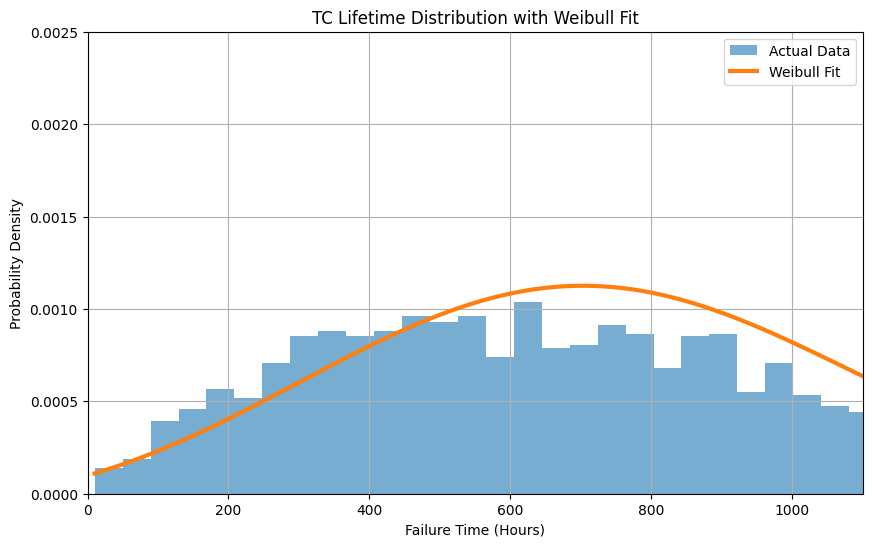

In [173]:

tc = df[
    df["Test_Type"] == "TC"
]

data = tc[
    "Failure_Time_Hours" 
]

shape, loc, scale = (
    stats.weibull_min.fit(data)
)

plt.figure(figsize=(10,6))

plt.hist(
    data,
    bins=30,
    density=True,
    alpha=0.6,
    label="Actual Data"
)

x = np.linspace(
    data.min(),
    data.max(),
    500
)

plt.plot(
    x,
    stats.weibull_min.pdf(
        x,
        shape,
        loc,
        scale
    ),
    linewidth=3,
    label="Weibull Fit"
)

plt.title(
    "TC Lifetime Distribution with Weibull Fit"
)

plt.xlabel(
    "Failure Time (Hours)"
)

plt.ylabel(
    "Probability Density"
)

plt.legend()

plt.grid(True)

plt.xlim(0,1100)
plt.ylim(0,0.0025)

plt.show()

A Weibull distribution provided the best statistical fit to the thermal cycling lifetime data, with the lowest KS statistic of 0.041. This is consistent with wear-out dominated failure mechanisms such as solder fatigue and thermomechanical degradation, which are commonly observed in semiconductor thermal cycling reliability studies.

## Batch Analysis

                mean      median         std
Batch_ID                                    
B1        907.359012  800.920569  569.384467
B2        951.432761  901.339582  577.485344
B3        842.200647  707.875466  556.127208
B4        962.894481  884.054781  578.471652


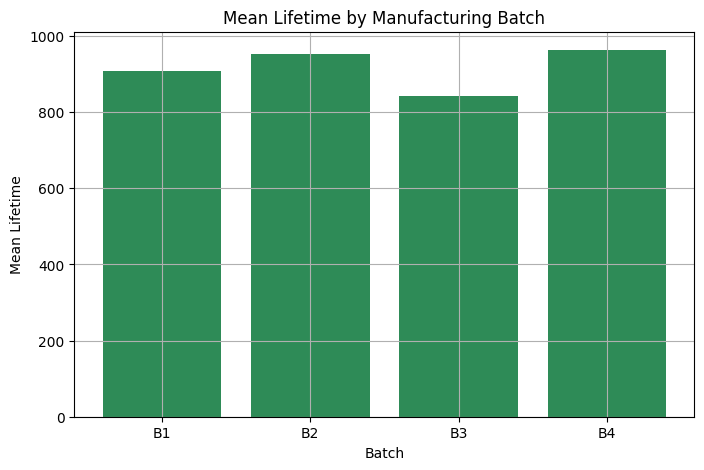

In [187]:
def analyze_batch_variation(df):

    result = (
        df.groupby(
            "Batch_ID"
        )[
            "Failure_Time_Hours"
        ]
        .agg(
            [
                "mean",
                "median",
                "std"
            ]
        )
    )

    print(result)

    plt.figure(
        figsize=(8,5)
    )

    plt.bar(
        result.index,
        result["mean"],
        color="seagreen"
    )

    plt.title(
        "Mean Lifetime by Manufacturing Batch"
    )

    plt.xlabel(
        "Batch"
    )

    plt.ylabel(
        "Mean Lifetime"
    )

    plt.grid(True)

    plt.show()


analyze_batch_variation(df)

Manufacturing variation affects reliability.

## Outlier Detection

In [179]:
def detect_outliers(df):

    working_df = df.copy()

    working_df["Z"] = zscore(
        working_df[
            "Failure_Time_Hours"
        ]
    )

    outliers = working_df[
        np.abs(
            working_df["Z"]
        )
        >
        3
    ]

    print(
        "\nTotal Outliers:",
        len(outliers)
    )

    print(
        outliers[
            [
                "Device_ID",
                "Test_Type",
                "Batch_ID",
                "Failure_Time_Hours"
            ]
        ]
        .head(20)
    )

    return outliers


outliers = detect_outliers(df)


Total Outliers: 0
Empty DataFrame
Columns: [Device_ID, Test_Type, Batch_ID, Failure_Time_Hours]
Index: []


The boxplot identifies outliers within each temperature subgroup, whereas the global outlier analysis was performed on the complete dataset. A point that appears extreme within a specific stress condition may still fall within the expected range of the overall reliability population.

## Reliability Report

In [180]:
def generate_reliability_report(df):

    print(
        "\n========== KEY FINDINGS ==========\n"
    )

    print(
        "1. Temperature is the dominant reliability driver."
    )

    print(
        "2. Increasing temperature reduces lifetime significantly."
    )

    print(
        "3. Voltage introduces additional acceleration."
    )

    print(
        "4. Batch-to-batch variation contributes to lifetime spread."
    )

    print(
        "5. Outliers indicate unusually early or late failures."
    )

    print(
        "6. Lifetime distributions are consistent with wear-out behaviour."
    )


generate_reliability_report(df)


========== KEY FINDINGS ==========

1. Temperature is the dominant reliability driver.
2. Increasing temperature reduces lifetime significantly.
3. Voltage introduces additional acceleration.
4. Batch-to-batch variation contributes to lifetime spread.
5. Outliers indicate unusually early or late failures.
6. Lifetime distributions are consistent with wear-out behaviour.
